In [16]:
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
from meteostat import Point, Hourly, Stations
from tqdm import tqdm
import sys
import numpy as np

In [17]:
sys.path.append('Utils/')
from PlotUtils import setMplParam, getColour, getHistoParam 
# getHistoParam: 
# Nbins, binwidth, bins, counts, bin_centers  = 
# from ExternalFunctions import nice_string_output, add_text_to_ax
setMplParam()

In [4]:
# Point object automatically finds the nearest weather station with a given lat/lon pair
locations = { 
             'Copenhagen': Point(lat=55.6761, lon=12.5683), 
             'Kiel': Point(lat=54.3233, lon=10.1228, alt=10), 
             'Bensheim': Point(lat=49.6780, lon=8.6220, alt=10), 
             'Kempten': Point(lat=47.7245, lon=10.1708, alt=10), 
             'Chicago': Point(lat=41.8781, lon=-87.6298, alt=10), 
             'Daegu': Point(lat=35.8714, lon=128.6014, alt=10),
             } 

In [5]:
def get_hourly_example(location: Point, start: datetime, end: datetime ) -> pd.DataFrame: 
    data = Hourly(location, start, end) 
    return data.fetch() 

In [6]:
def plot_hourly_temperature(all_data: dict) -> None: 
    fig, ax = plt.subplots(figsize=(17, 7)) 

    for city_name, df in all_data.items(): 
        print(f"Plotting data for {city_name}...")  
        if 'temp' in df.columns: 
            df['temp'].plot(ax=ax, label=city_name) 
        else: 
            print(f"[{city_name}] 'temp' column missing – skipping.") 

    ax.set_title("Hourly Temperature Comparison") 
    ax.set_xlabel("Date") 
    ax.set_ylabel("Temperature (°C)") 
    ax.legend() 
    plt.tight_layout() 
    plt.show()

In [7]:
def run(start: datetime, end: datetime) -> None: 
    all_data = {} 

    for city, location in tqdm(locations.items(), desc="Cities"): 
        tqdm.write(f"[{city}] Fetching hourly data...") 
        try: 
            hourly_data = get_hourly_example(location, start, end) 
            if not hourly_data.empty: 
                all_data[city] = hourly_data 
                tqdm.write(f"[{city}] ✅ Data loaded") 
            else: 
                tqdm.write(f"[{city}] ⚠️ No data available.") 
        except Exception as e: 
            tqdm.write(f"[{city}] ❌ Error: {e}") 

    if all_data:
        plot_hourly_temperature(all_data)

Cities:   0%|          | 0/6 [00:00<?, ?it/s]

[Copenhagen] Fetching hourly data...


[Copenhagen] ✅ Data loaded


Cities:  17%|█▋        | 1/6 [00:05<00:25,  5.14s/it]

[Kiel] Fetching hourly data...


...

[Bensheim] ✅ Data loaded
[Kempten] Fetching hourly data...
[Kempten] ❌ Error: 'Hourly' object has no attribute '_types'
[Chicago] Fetching hourly data...


Cities:  83%|████████▎ | 5/6 [00:34<00:07,  7.07s/it]

[Chicago] ✅ Data loaded
[Daegu] Fetching hourly data...


Cities: 100%|██████████| 6/6 [00:44<00:00,  7.38s/it]


[Daegu] ✅ Data loaded
Plotting data for Copenhagen...
Plotting data for Kiel...
Plotting data for Bensheim...
Plotting data for Chicago...
Plotting data for Daegu...


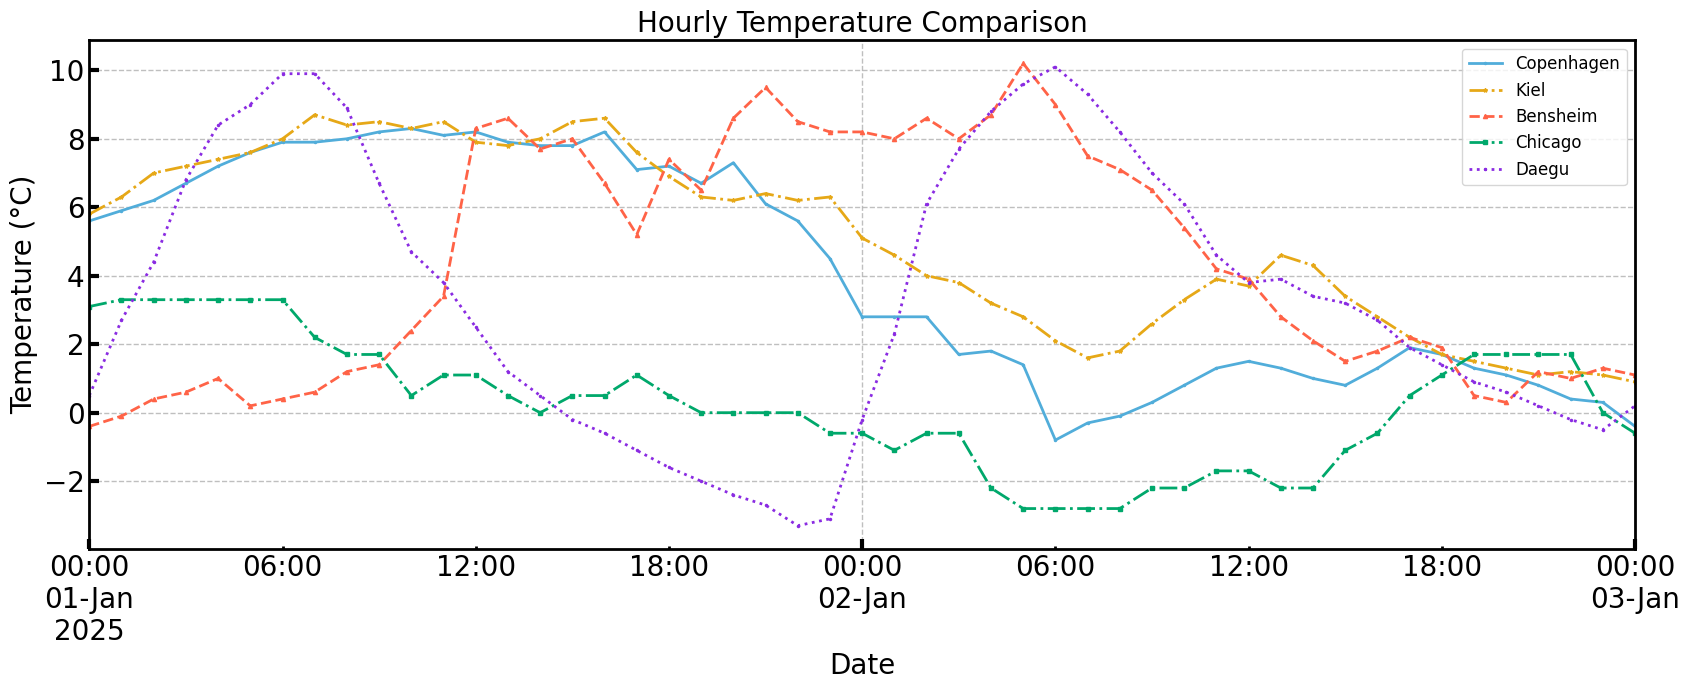

In [8]:
run(start=datetime(2025, 1, 1), end=datetime(2025, 1, 3))

Cities:   0%|          | 0/6 [00:00<?, ?it/s]

[Copenhagen] Fetching hourly data...


Cities:  17%|█▋        | 1/6 [00:00<00:02,  2.43it/s]

[Copenhagen] ✅ Data loaded
[Kiel] Fetching hourly data...


Cities:  33%|███▎      | 2/6 [00:02<00:06,  1.53s/it]

...

[Bensheim] ✅ Data loaded
[Kempten] Fetching hourly data...
[Kempten] ❌ Error: 'Hourly' object has no attribute '_types'
[Chicago] Fetching hourly data...


Cities:  83%|████████▎ | 5/6 [00:12<00:02,  2.31s/it]

[Chicago] ✅ Data loaded
[Daegu] Fetching hourly data...


Cities: 100%|██████████| 6/6 [00:12<00:00,  2.15s/it]


[Daegu] ✅ Data loaded
Plotting data for Copenhagen...
Plotting data for Kiel...
Plotting data for Bensheim...
Plotting data for Chicago...
Plotting data for Daegu...


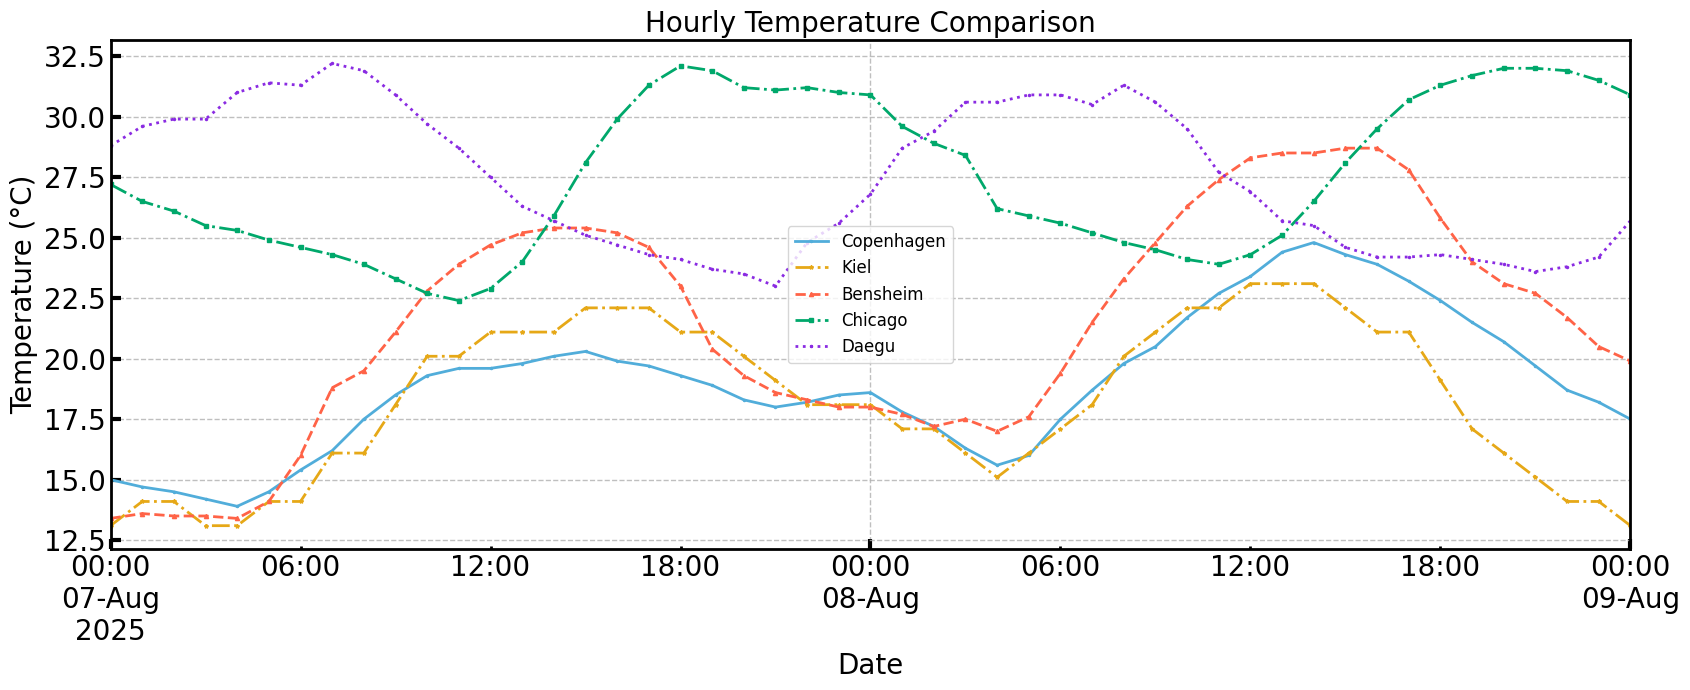

In [9]:
run(start=datetime(2025, 8, 7), end=datetime(2025, 8, 9))

In [10]:
def isClean(df: pd.DataFrame) -> bool:
    """
    Return True if the DataFrame contains no NaN values.
    If NaNs exist, print each column with its NaN count and return False.
    """
    _is_clean = False
    nan_counts = df.isna().sum()
    nan_columns = nan_counts[nan_counts > 0]
    
    if nan_columns.empty:
        _is_clean = True
    else:
        print("NaN values detected in the following columns:")
        for col, count in nan_columns.items():
            print(f"  → Column: '{col}', NaN count: {count}")

    return _is_clean

In [12]:
example_df = get_hourly_example(locations['Copenhagen'], start=datetime(2025, 1, 1), end=datetime(2025, 10, 3))
isClean(example_df)

NaN values detected in the following columns:
  → Column: 'prcp', NaN count: 175
  → Column: 'snow', NaN count: 6601
  → Column: 'tsun', NaN count: 6601


False

In [13]:
example_df['prcp'].describe()

count      6426.0
mean      0.04488
std      0.262759
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           8.0
Name: prcp, dtype: Float64

<Axes: title={'center': 'Precipitation (prcp) over Time'}, xlabel='time'>

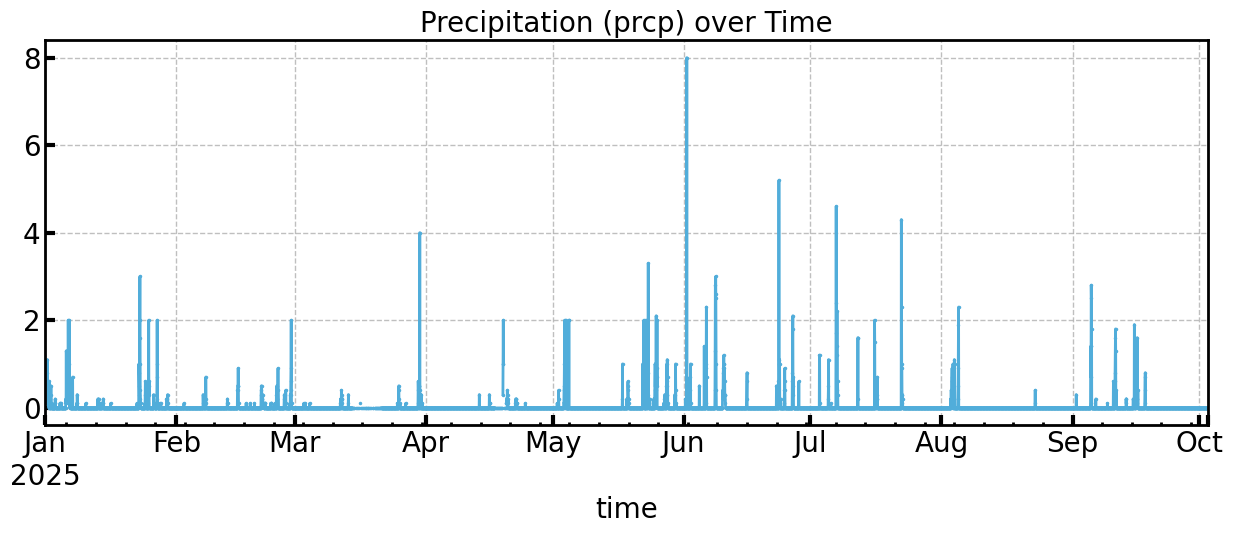

In [14]:
example_df['prcp'].plot(figsize=(15,5), title='Precipitation (prcp) over Time')

<Axes: title={'center': 'Transformed Precipitation (prcp) over Time'}, xlabel='time'>

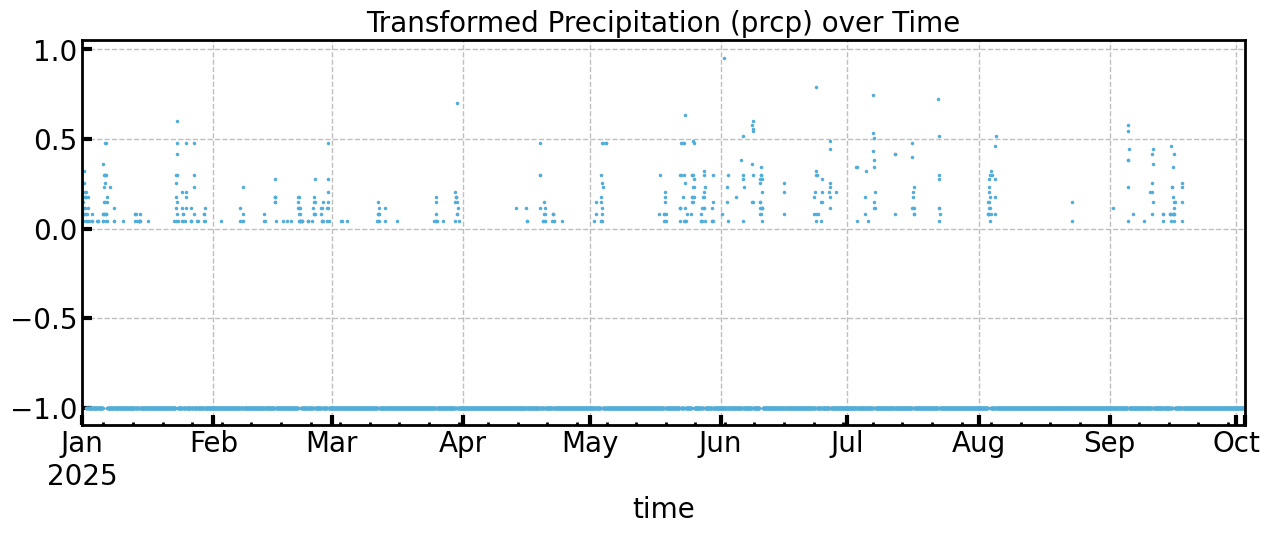

In [18]:
example_df['prcp_filled'] = example_df['prcp'].fillna(0)
example_df['prcp_t'] = np.where(
    example_df['prcp_filled'] > 0,
    np.log10(example_df['prcp_filled'] + 1),
    -1
)


example_df['prcp_t'].plot(figsize=(15,5), title='Transformed Precipitation (prcp) over Time', linestyle='None')

In [19]:
example_df['prcp_t'].describe()

count    6601.000000
mean       -0.912978
std         0.309650
min        -1.000000
25%        -1.000000
50%        -1.000000
75%        -1.000000
max         0.954243
Name: prcp_t, dtype: float64

In [20]:
example_df['wspd'].describe()

count      6601.0
mean     15.61468
std      7.866946
min           0.0
25%           9.4
50%          14.8
75%          20.5
max          55.4
Name: wspd, dtype: Float64

<Axes: title={'center': 'Wind Speed (wspd) over Time'}, xlabel='time'>

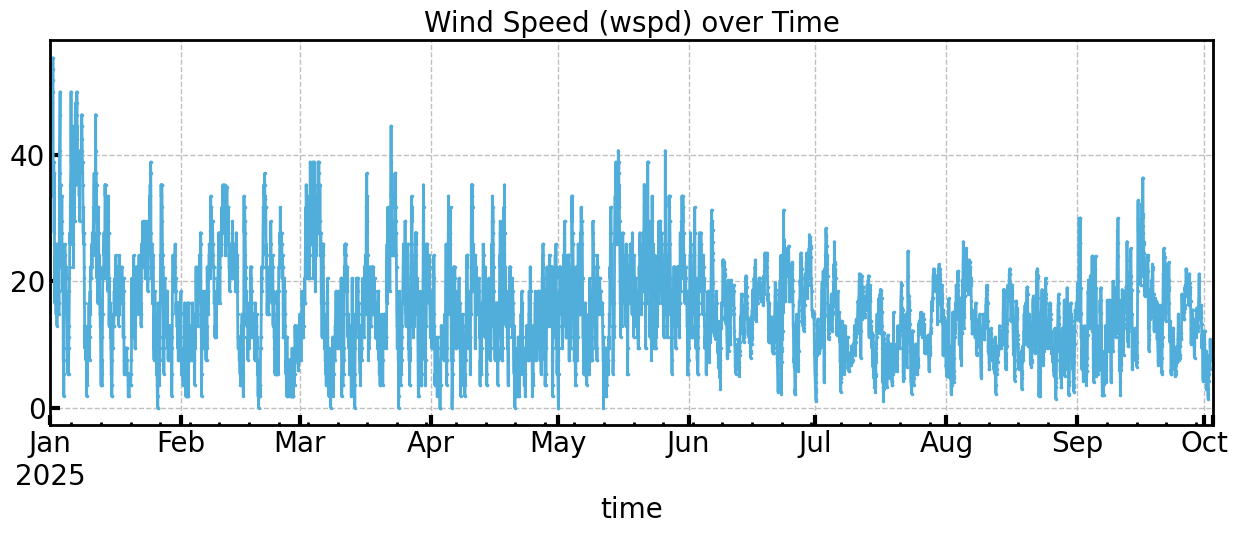

In [21]:
example_df['wspd'].plot(figsize=(15,5), title='Wind Speed (wspd) over Time')

<Axes: title={'center': 'Transformed Wind Speed (wspd) over Time'}, xlabel='time'>

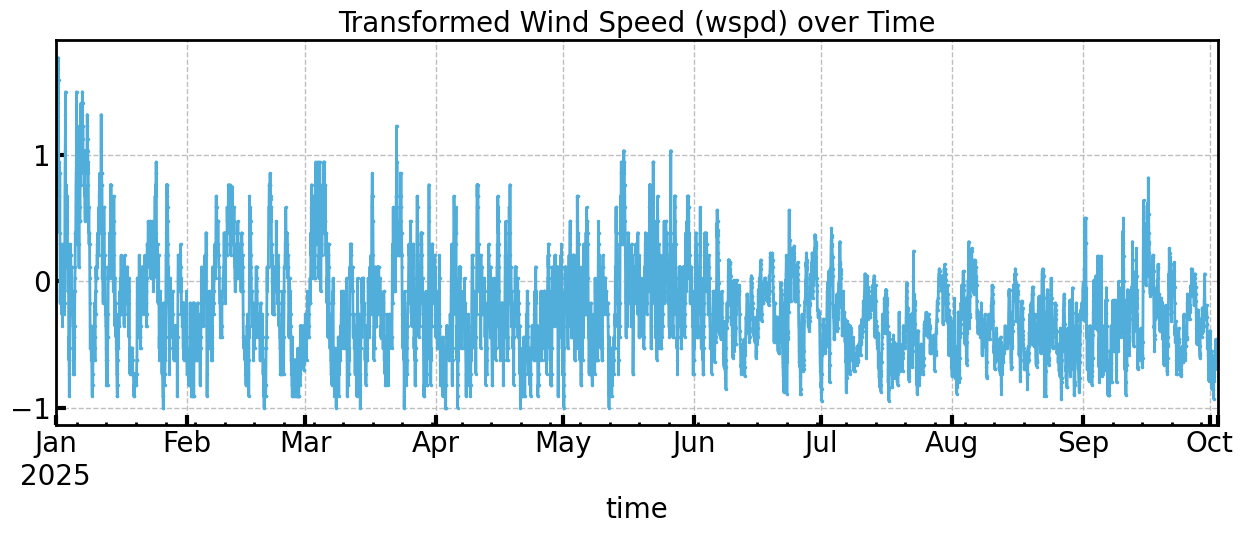

In [22]:
example_df['wspd_t']= (example_df['wspd']-20)/20
example_df['wspd_t'].plot(figsize=(15,5), title='Transformed Wind Speed (wspd) over Time')

<Axes: title={'center': 'Wind Gust Speed (wpgt) over Time'}, xlabel='time'>

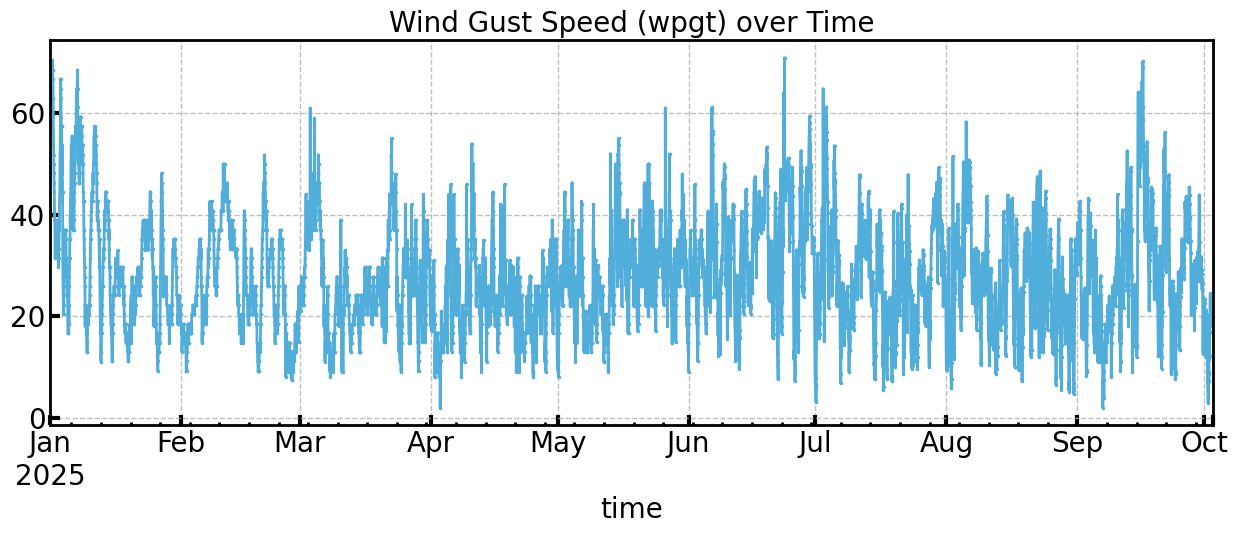

In [23]:
example_df['wpgt'].plot(figsize=(15,5), title='Wind Gust Speed (wpgt) over Time')

<Axes: title={'center': 'Transformed Wind Gust Speed (wpgt) over Time'}, xlabel='time'>

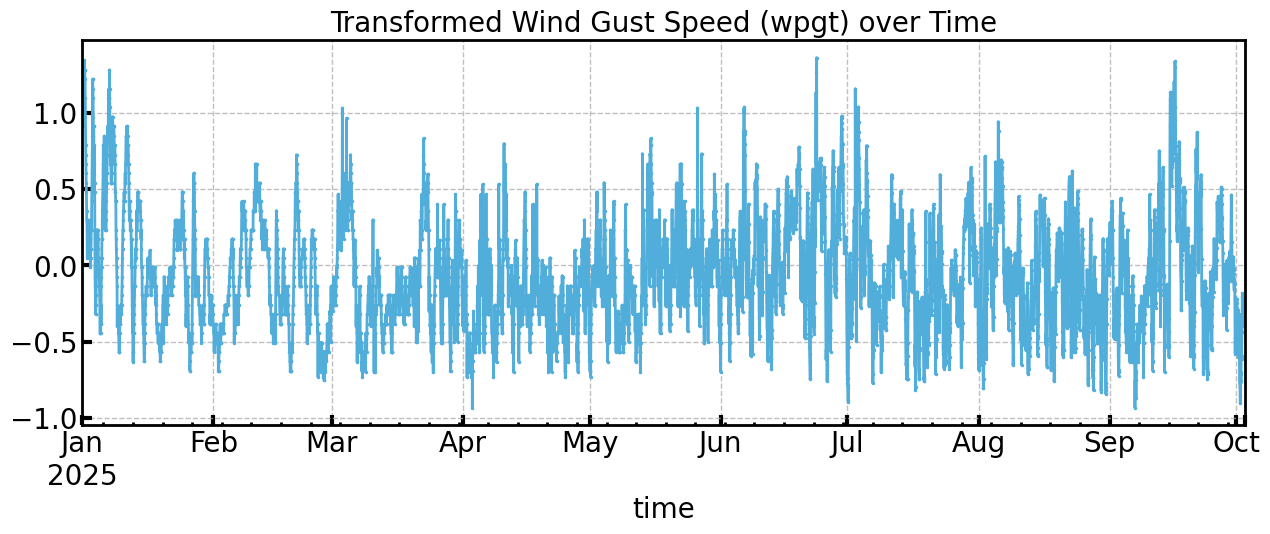

In [24]:
example_df['wpgt_t']= (example_df['wpgt']-30)/30
example_df['wpgt_t'].plot(figsize=(15,5), title='Transformed Wind Gust Speed (wpgt) over Time')